# Распределение признаков

C:\Users\Максим\AppData\Local\Temp\ipykernel_15908\1957174743.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y, palette='pastel')


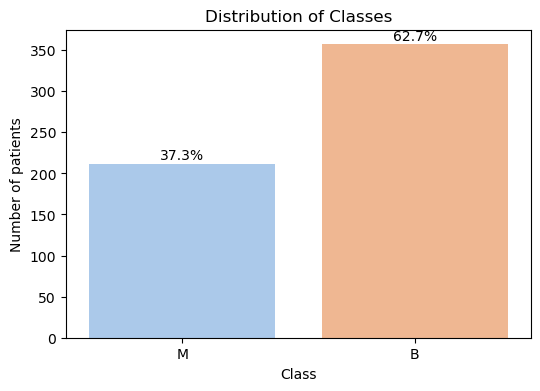

In [49]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x=y, palette='pastel')

for p in ax.patches:
    height = p.get_height()
    percent = height / total * 100
    ax.text(
        p.get_x() + p.get_width() / 2.,
        height + 5,     
        f'{percent:.1f}%',
        ha='center'                     
    )

ax.set_xlabel('Class')
ax.set_ylabel('Number of patients')
ax.set_title('Distribution of Classes')

plt.show()

In [52]:
X.describe().T.style.bar(subset=['mean'], color='#205ff2')\
                            .background_gradient(subset=['std'], cmap='Reds')\
                            .background_gradient(subset=['50%'], cmap='Reds')

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
fractal_dimension_mean,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


Целевые значения разделены в соотношении 63/37. Разный маштаб, особенно area_worst, area_mean с остальными - нужна стандартизация.

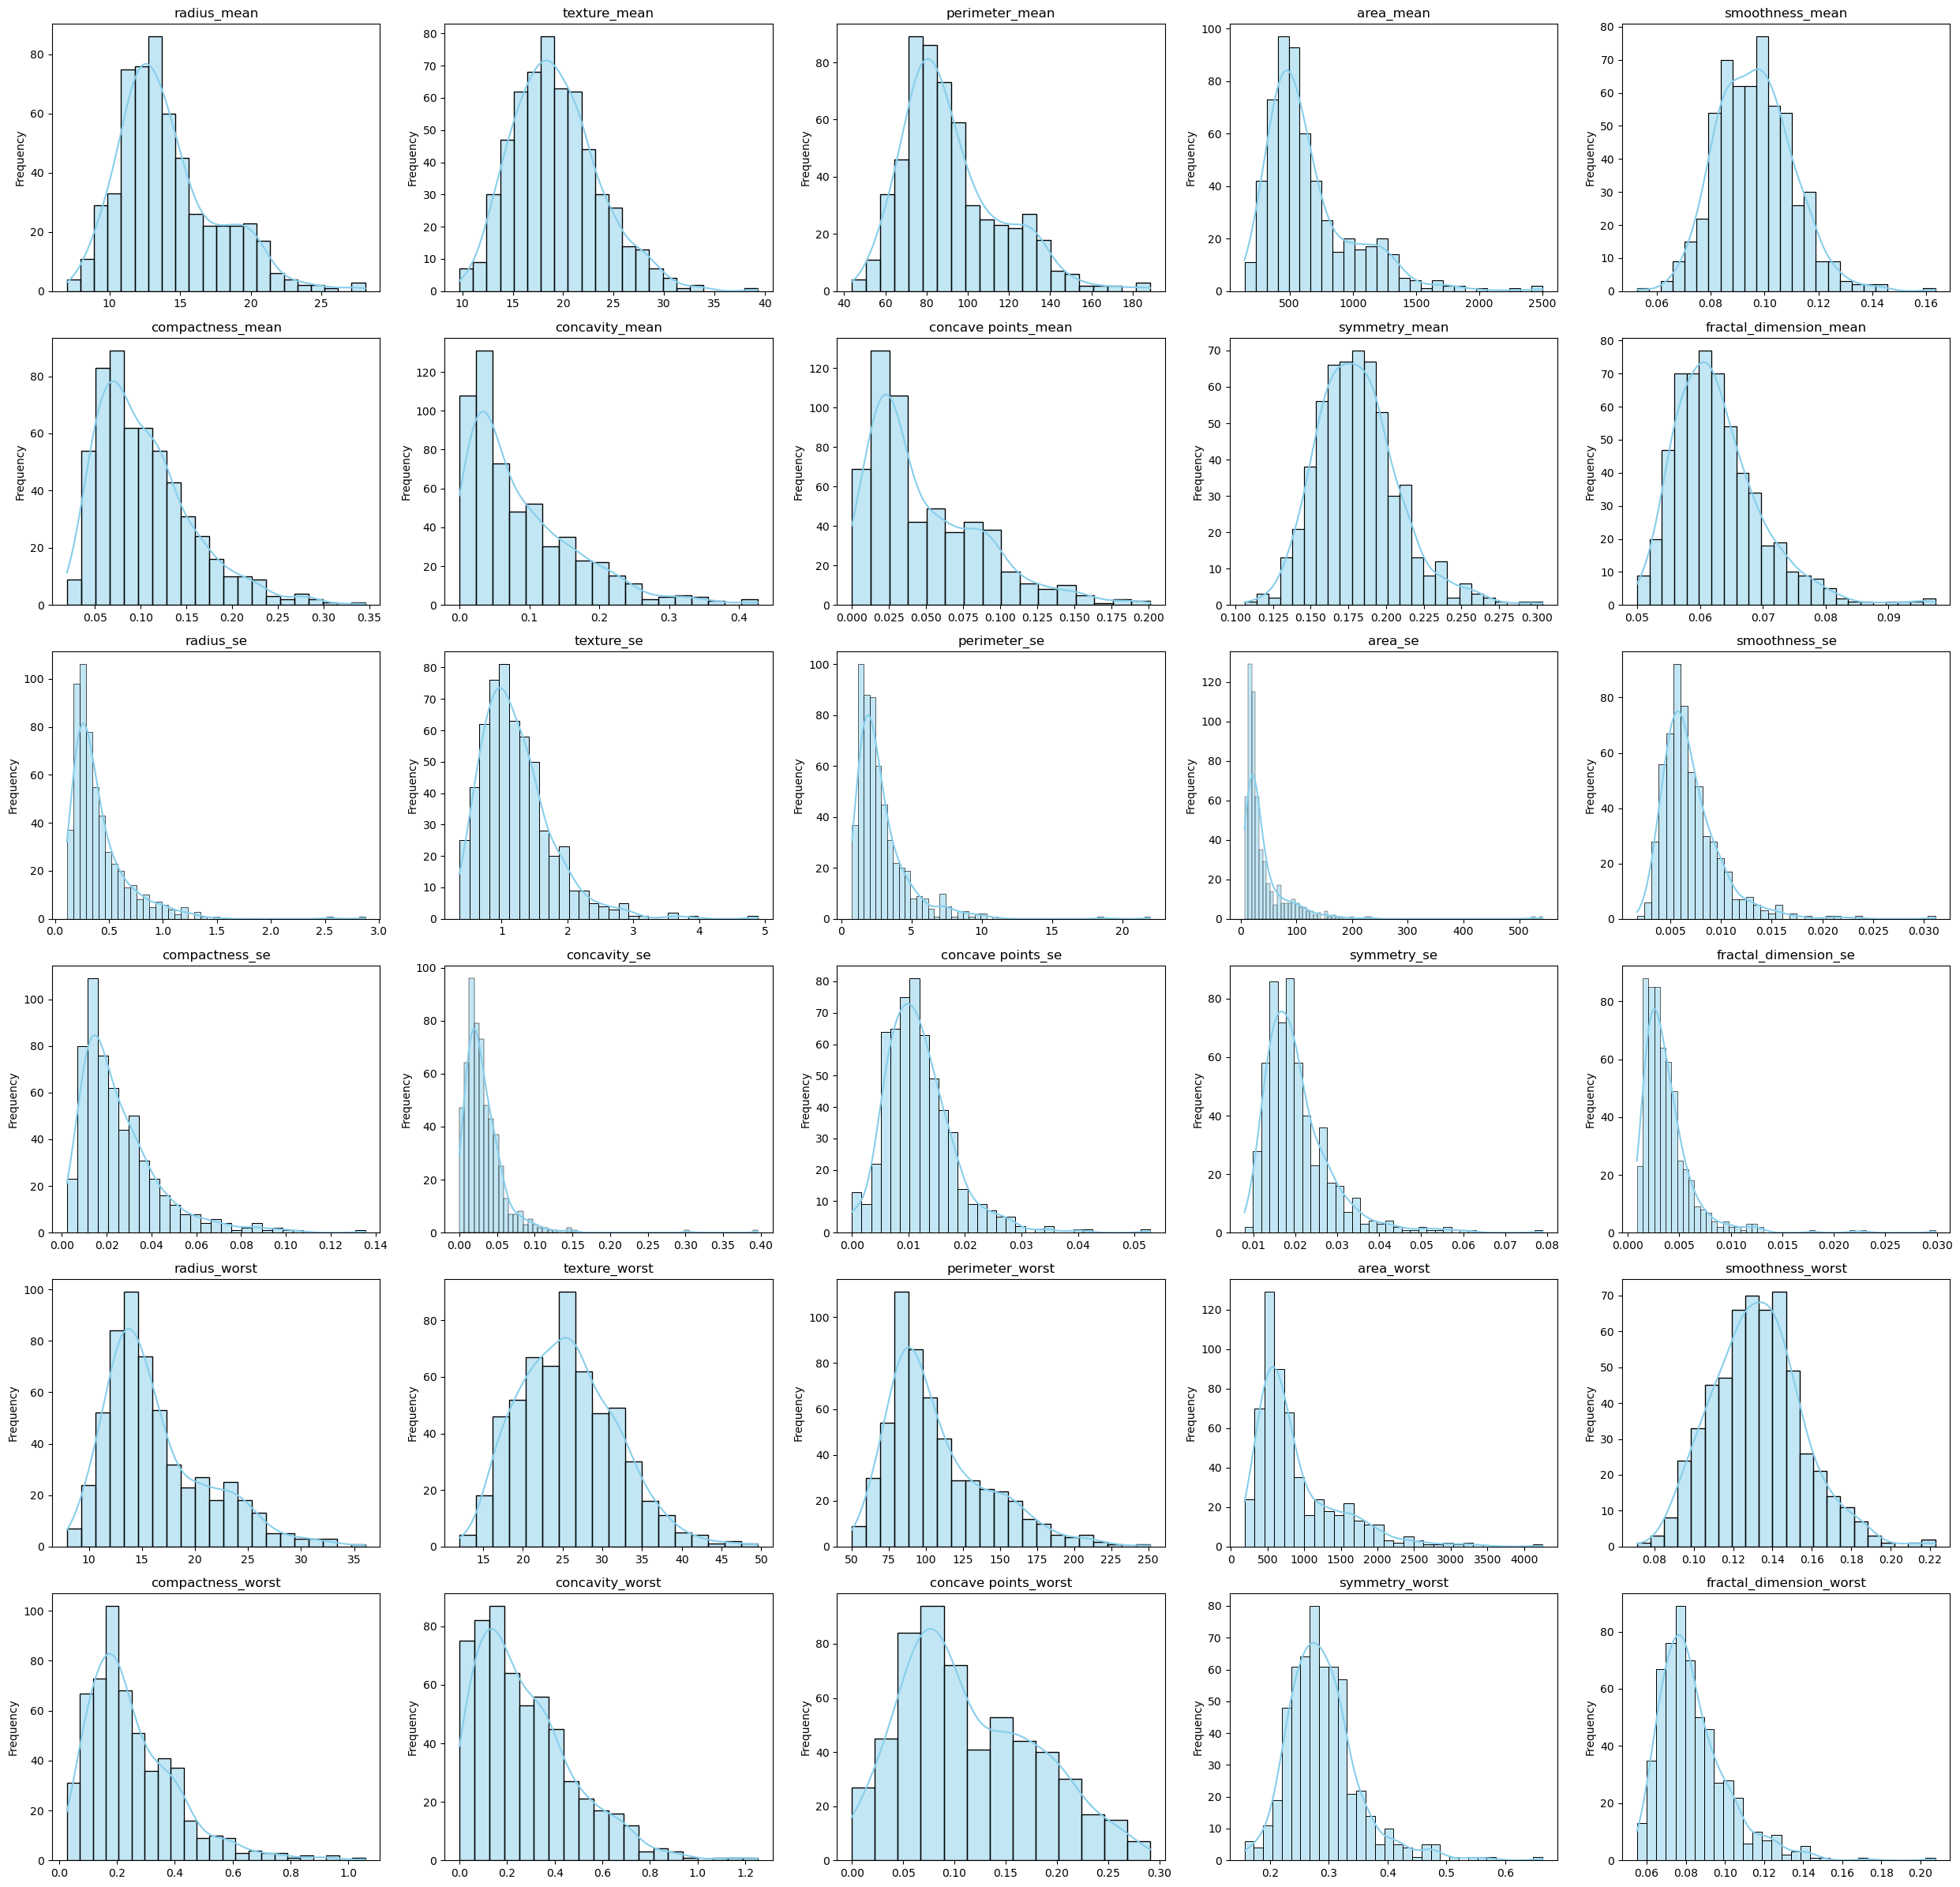

In [57]:
num_cols = X.select_dtypes(include='number').columns

n_cols = 5
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(X[col].dropna(), kde=True, color='skyblue')
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Данные распределены не нормально, имеются сильная скошенность вправо, выбросы. Планируется выбор из логистической регрессии, Decision Tree, Random Forest, SVM (linear), SVM (RBF), XGBoost. Для стандартизации будем использовать RobustScaler

C:\Users\Максим\AppData\Local\Temp\ipykernel_15908\3572953245.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


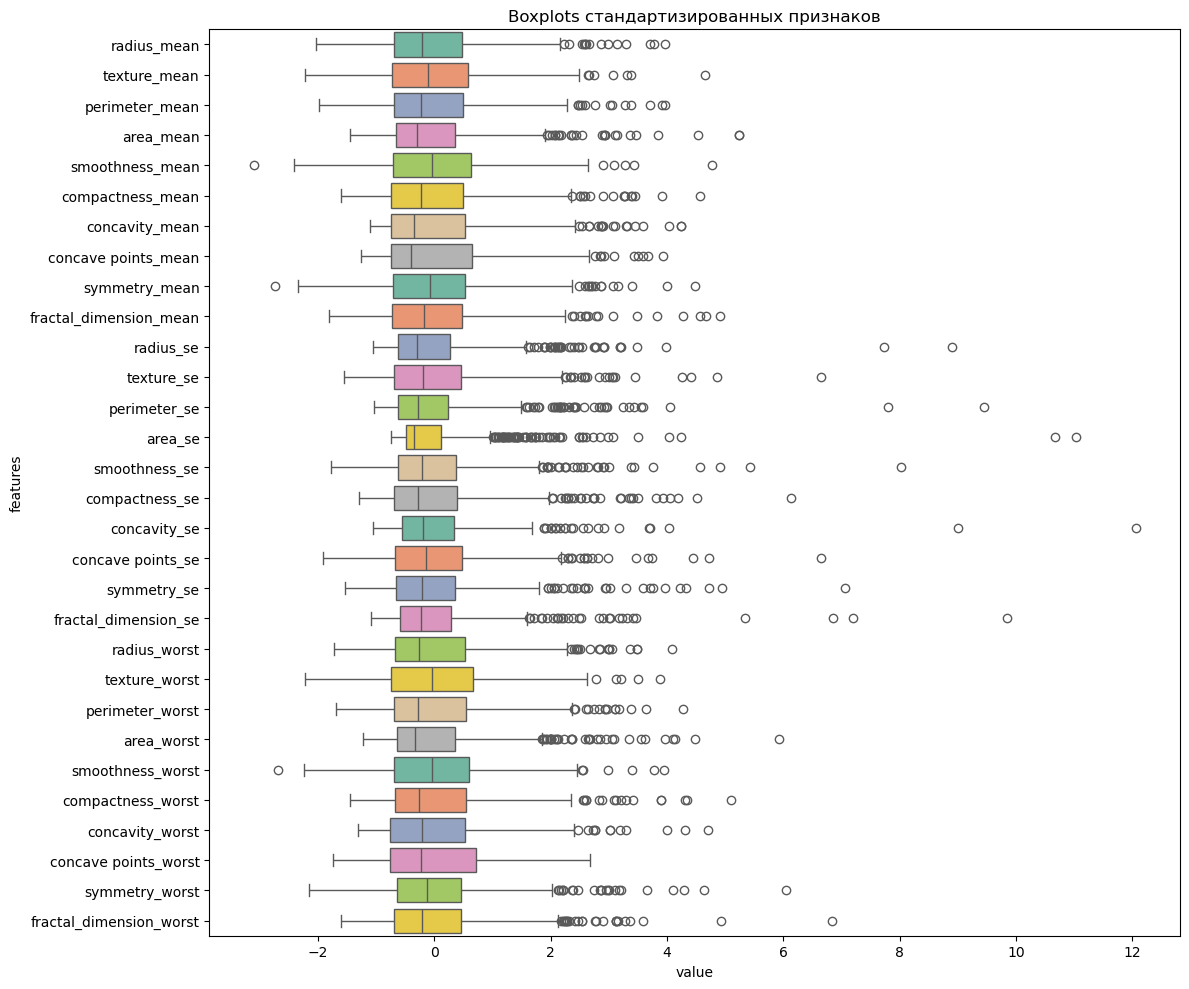

In [64]:
df_stand = (X - X.mean()) / X.std()

data_melt = pd.melt(df_stand, var_name="features", value_name="value")

plt.figure(figsize=(12,10))
sns.boxplot(
    y="features",
    x="value",
    data=data_melt,
    palette="Set2"
)

plt.title("Boxplots стандартизированных признаков")
plt.tight_layout()
plt.show()


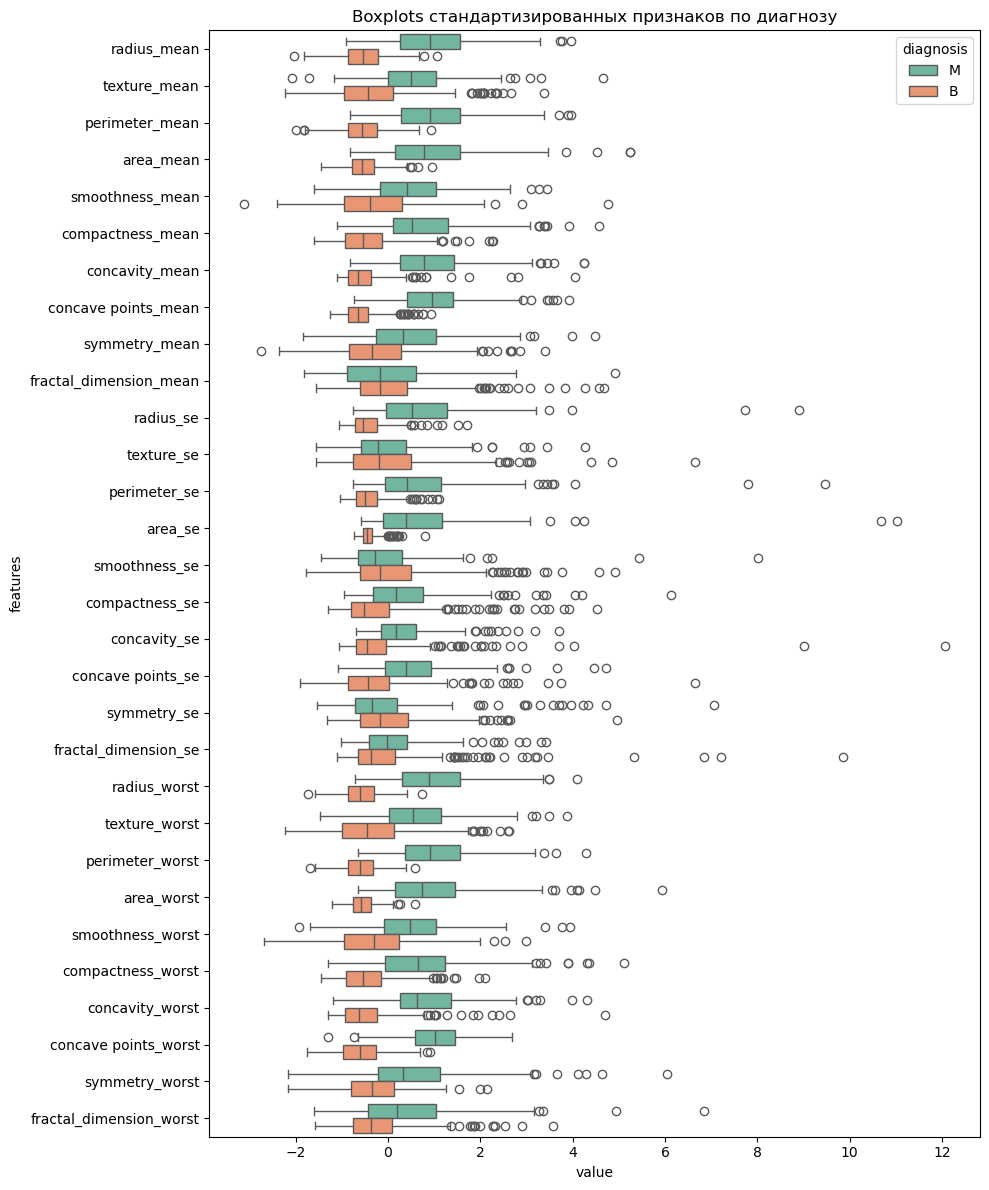

In [66]:
data = pd.concat([y, df_stand], axis=1)
data_melt = pd.melt(data, id_vars="diagnosis", var_name="features", value_name="value")

plt.figure(figsize=(10,12))
sns.boxplot(
    y="features", 
    x="value", 
    hue="diagnosis", 
    data=data_melt, 
    palette="Set2",
    dodge=True
)

plt.title("Boxplots стандартизированных признаков по диагнозу")
plt.tight_layout()
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'radius_mean'),
  Text(1, 0, 'texture_mean'),
  Text(2, 0, 'perimeter_mean'),
  Text(3, 0, 'area_mean'),
  Text(4, 0, 'smoothness_mean'),
  Text(5, 0, 'compactness_mean'),
  Text(6, 0, 'concavity_mean'),
  Text(7, 0, 'concave points_mean'),
  Text(8, 0, 'symmetry_mean'),
  Text(9, 0, 'fractal_dimension_mean'),
  Text(10, 0, 'radius_se'),
  Text(11, 0, 'texture_se'),
  Text(12, 0, 'perimeter_se'),
  Text(13, 0, 'area_se'),
  Text(14, 0, 'smoothness_se')])

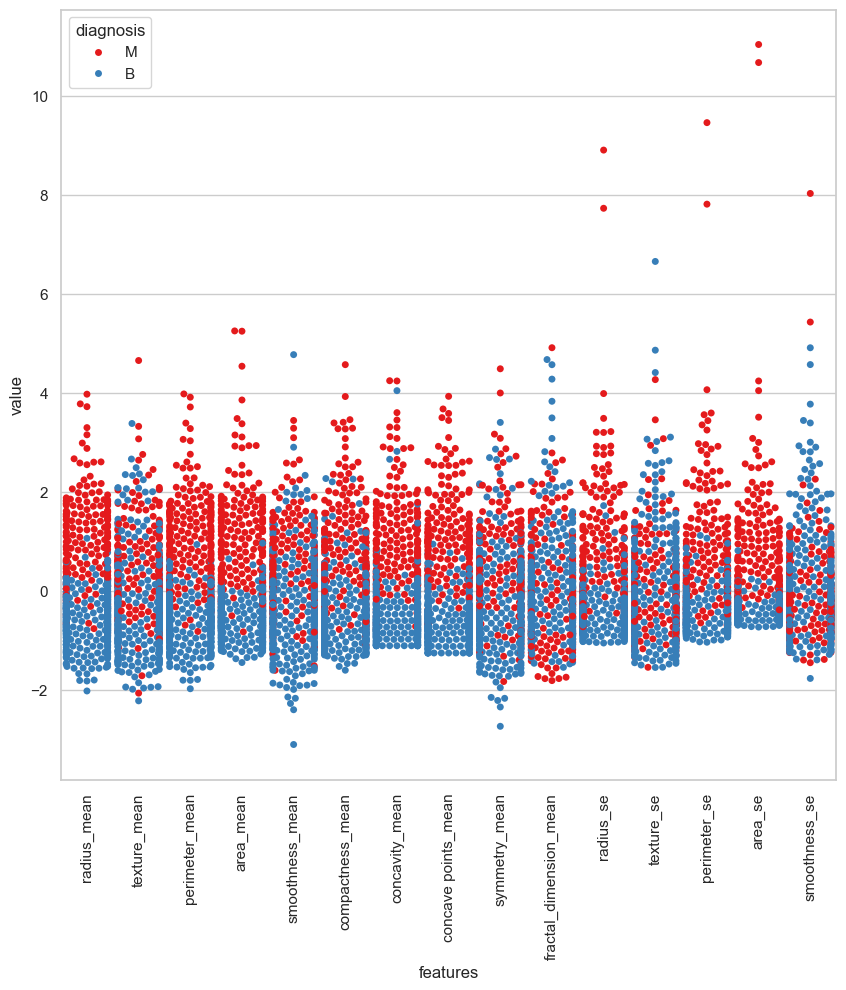

In [69]:
data = pd.concat([y,df_stand.iloc[:,0:15]],axis=1)
data = pd.melt(data,id_vars="diagnosis",
                    var_name="features",
                    value_name='value')

sns.set(style="whitegrid", palette="Set1")
plt.figure(figsize=(10,10))

sns.swarmplot(x="features", y="value", hue="diagnosis", data=data)
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'compactness_se'),
  Text(1, 0, 'concavity_se'),
  Text(2, 0, 'concave points_se'),
  Text(3, 0, 'symmetry_se'),
  Text(4, 0, 'fractal_dimension_se'),
  Text(5, 0, 'radius_worst'),
  Text(6, 0, 'texture_worst'),
  Text(7, 0, 'perimeter_worst'),
  Text(8, 0, 'area_worst'),
  Text(9, 0, 'smoothness_worst'),
  Text(10, 0, 'compactness_worst'),
  Text(11, 0, 'concavity_worst'),
  Text(12, 0, 'concave points_worst'),
  Text(13, 0, 'symmetry_worst'),
  Text(14, 0, 'fractal_dimension_worst')])

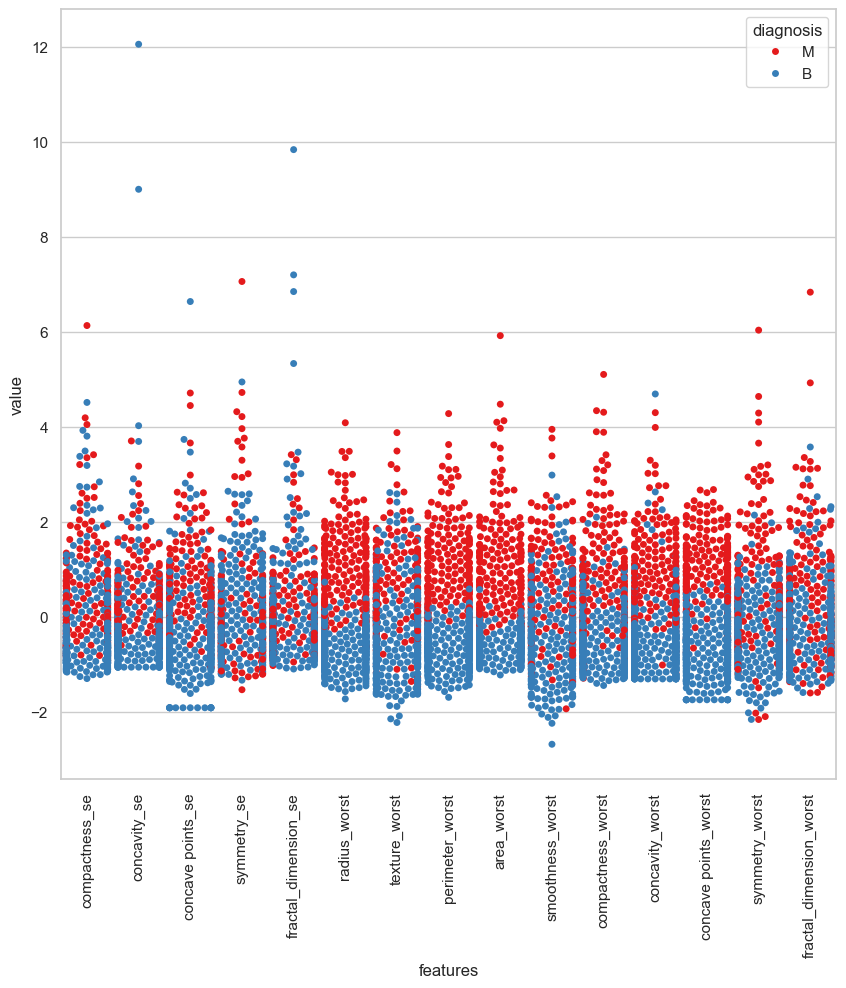

In [73]:
data = pd.concat([y,df_stand.iloc[:,15:30]],axis=1)
data = pd.melt(data,id_vars="diagnosis",
                    var_name="features",
                    value_name='value')
plt.figure(figsize=(10,10))
sns.swarmplot(x="features", y="value", hue="diagnosis", data=data)
plt.xticks(rotation=90)

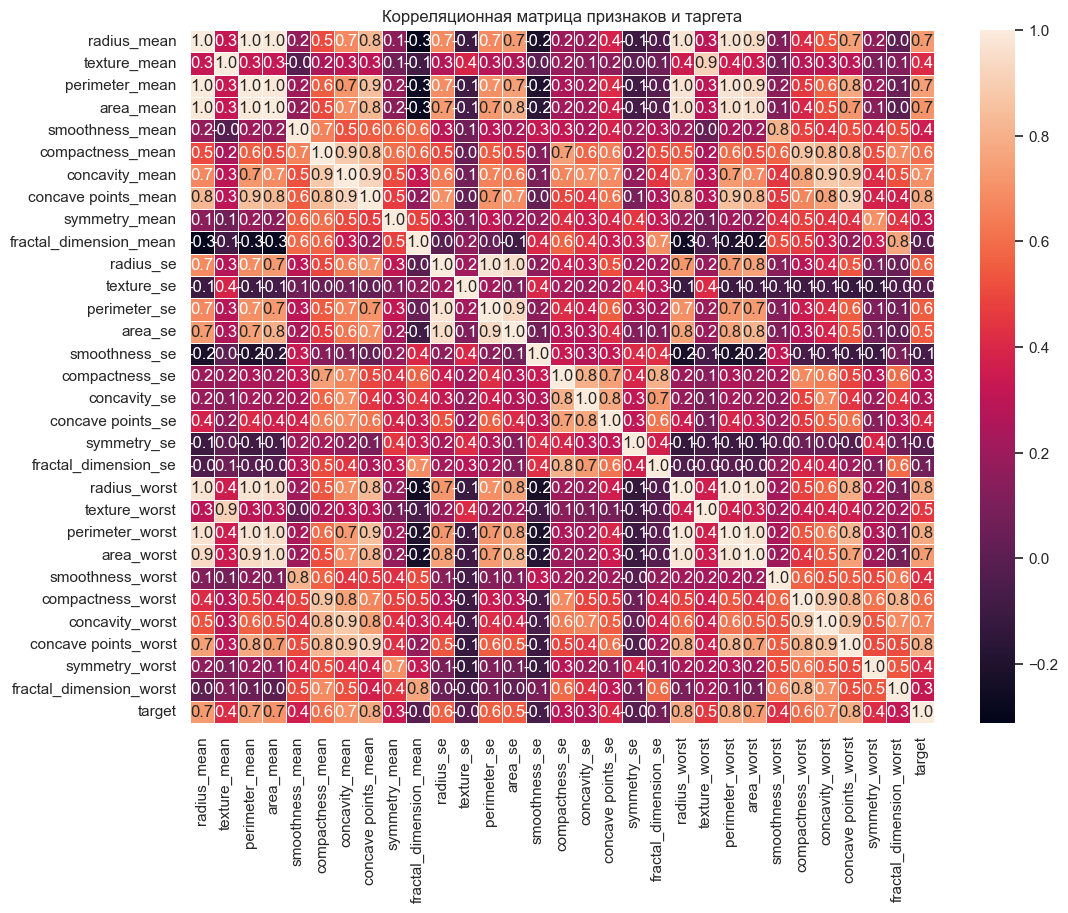

In [91]:
data_for_hm = X.copy()
data_for_hm['target'] = y.map({'B':0, 'M':1})

corrmat = data_for_hm.corr()

f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, annot=True, linewidths=.5, fmt='.1f', ax=ax)
plt.title("Корреляционная матрица признаков и таргета")
plt.show()


Предварительный анализ показал, что все признаки распределены ненормально, имеют выбросы и разный масштаб значений.
На boxplot и роевых графиках видно, что часть признаков (например, concavity_worst, area_mean, smoothness_worst) хорошо разделяет классы, тогда как другие — слабее.
Тепловая карта выявила группы сильно коррелирующих признаков, что указывает на необходимость отбора, чтобы избежать избыточности.
В целом, уже на этом этапе можно выделить признаки, которые перспективны для дальнейшего анализа и построения модели.

<Axes: >

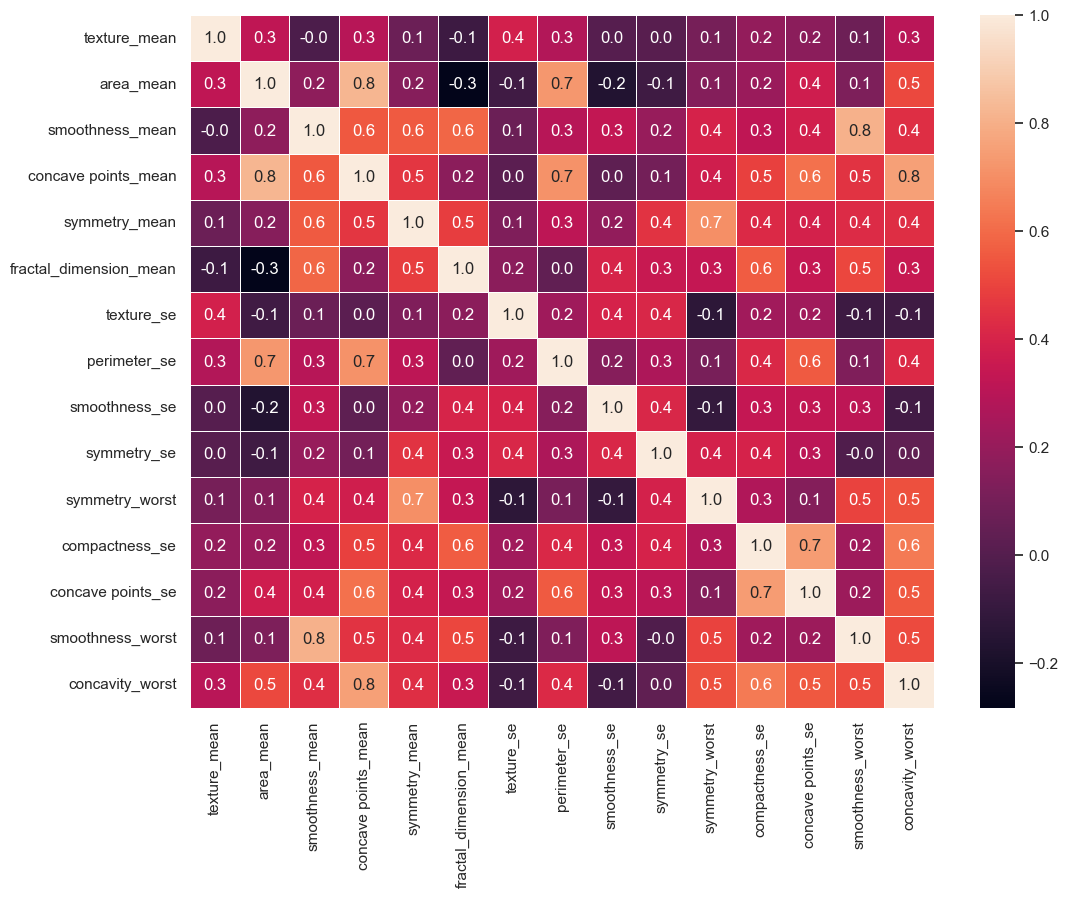

In [183]:
corrmat = X_filtered.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, annot=True, linewidths=.5, fmt= '.1f',ax=ax)

<Figure size 1200x1200 with 0 Axes>

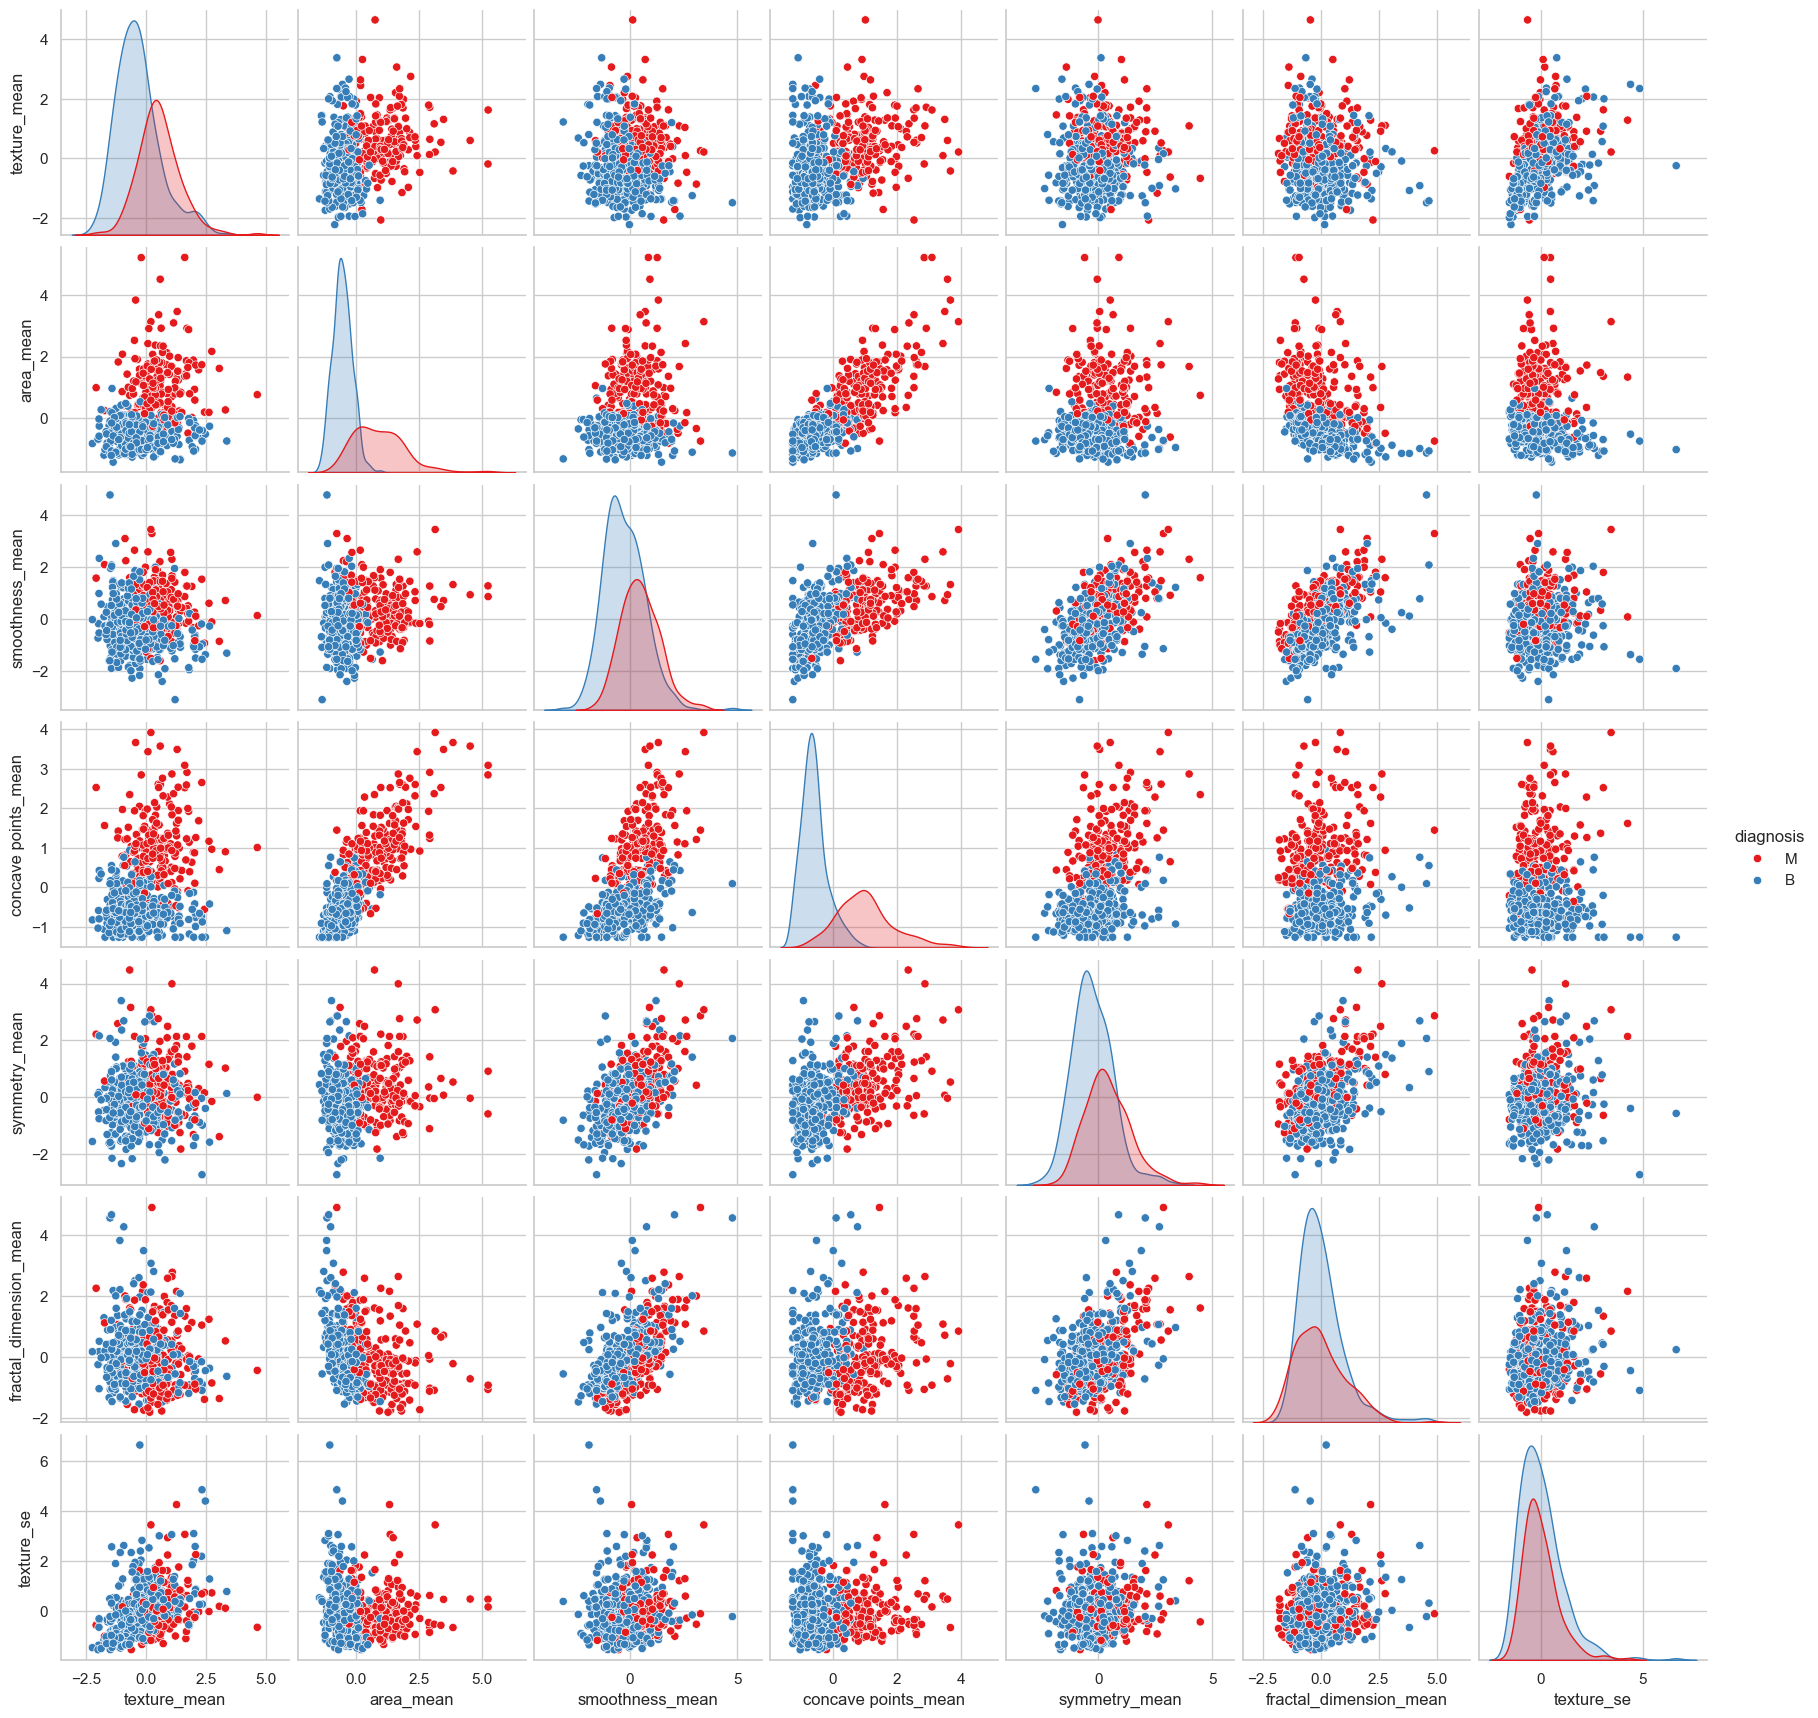

In [187]:
X_norm = (X_filtered - X_filtered.mean()) / X_filtered.std()

data_1 = pd.concat([y, X_norm.iloc[:,0:7]], axis=1)

plt.figure(figsize=(12, 12))
grid = sns.pairplot(data=data_1, kind="scatter", hue="diagnosis", palette="Set1")
plt.show()

<Figure size 1200x1200 with 0 Axes>

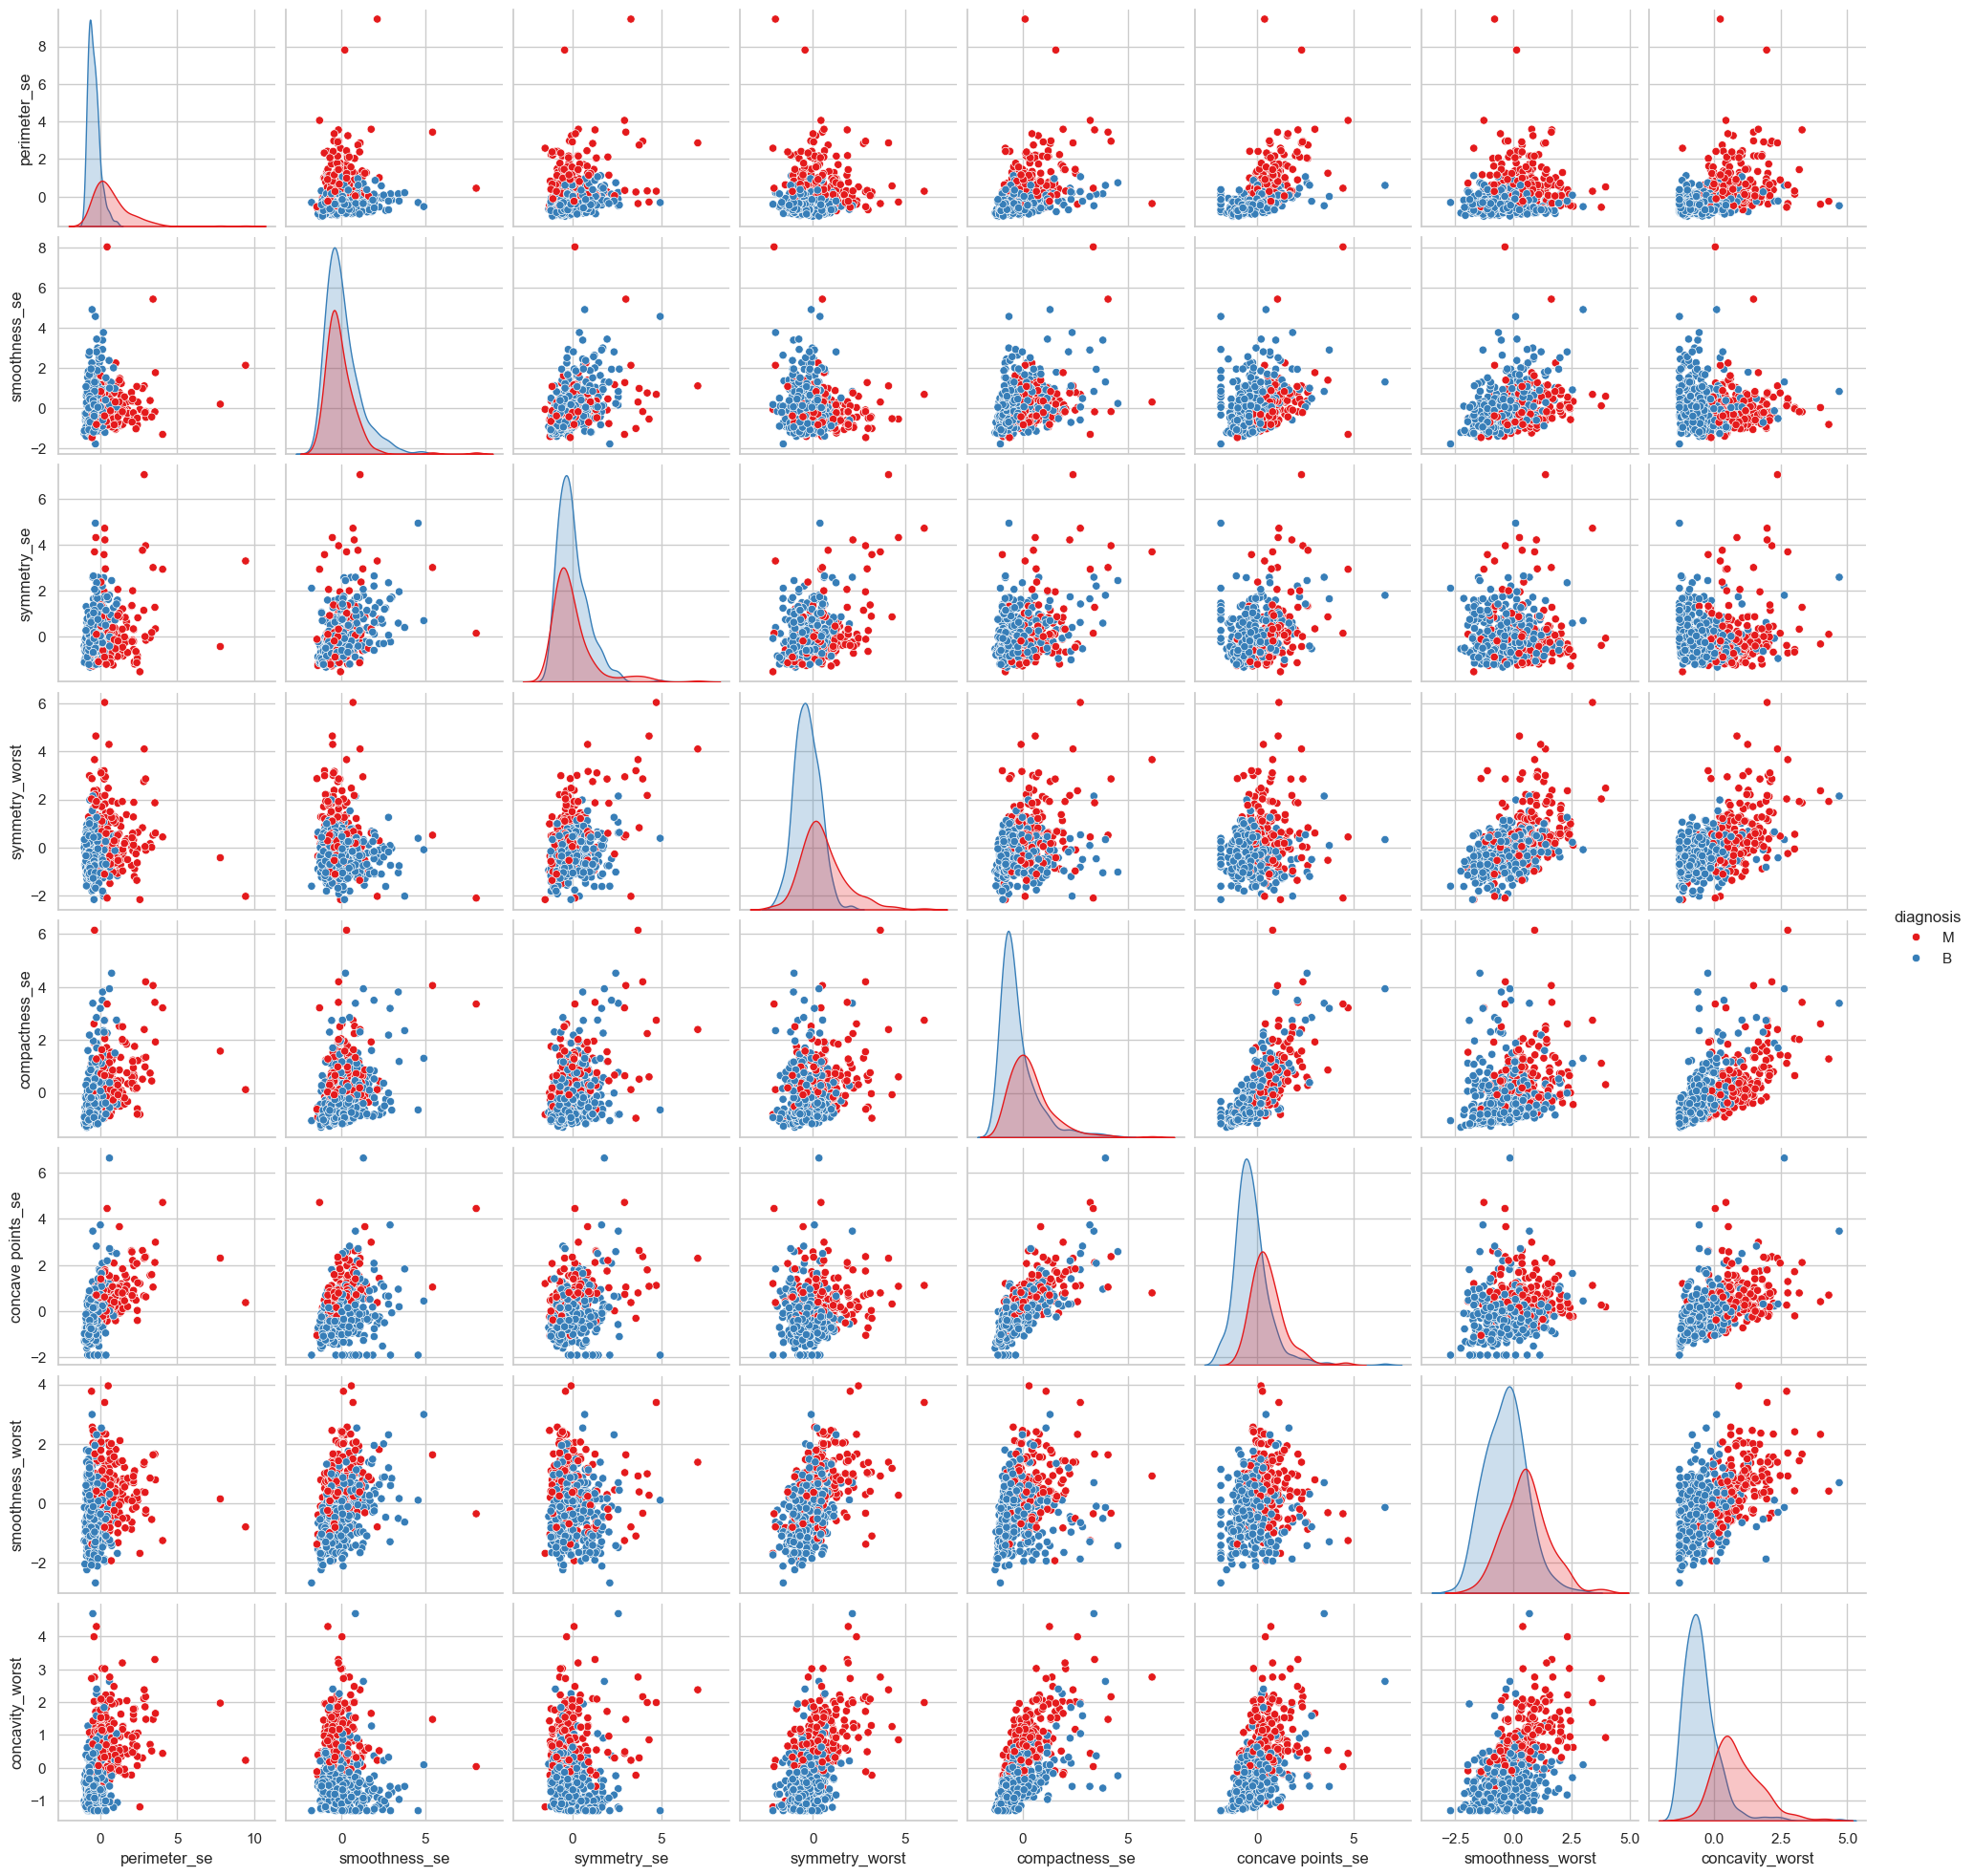

In [189]:
data_2 = pd.concat([y, X_norm.iloc[:,7:]], axis=1)

plt.figure(figsize=(12, 12))
grid = sns.pairplot(data=data_2, kind="scatter", hue="diagnosis", palette="Set1")
plt.show()

Все признаки имеют распределение, отличное от нормального, что подтверждено тестом Шапиро–Уилка, boxplot и гистограммами. На основе тепловой карты корреляций, boxplot с разделением по целевой переменной и роевого графика отобраны признаки с низкой взаимной корреляцией и наилучшим разделением классов. Перед отбором значения были стандартизированы для устранения различий в масштабе признаков.
Отобранные признаки
- texture_mean — отражает особенности текстуры ткани, различия выражены между классами.
- area_mean — показатель среднего размера образования, хорошо разделяет классы.
- smoothness_mean — характеризует однородность контуров.
- concave points_mean — фиксирует вогнутость границ, сильный предиктор.
- symmetry_mean — описывает асимметрию, различия заметны по классам.
- fractal_dimension_mean — отражает сложность границ образования.
- texture_se — показывает вариабельность текстуры, дополняет texture_mean.
- perimeter_se — изменчивость периметра, добавляет информацию о размере и форме.
- smoothness_se — вариабельность гладкости, помогает выявлять нестабильные образования.
- symmetry_se — изменчивость симметрии, усиливает значимость symmetry_mean.
- symmetry_worst — крайние значения асимметрии, хорошо различают классы.
- compactness_se — изменчивость компактности, отражает неоднородность структуры.
- concave points_se — изменчивость вогнутости, усиливает информативность concave points_mean.
- smoothness_worst — экстремальные значения гладкости, усиливают значение smoothness_mean.
- concavity_worst — максимальные проявления вогнутости, критически важны для разделения классов.

Выбранный нормализованный поднабор обладает низкой избыточностью и высокой предсказательной способностью. Наличие признаков как среднего уровня, так и вариабельности и «worst»-значений обеспечивает более устойчивое разделение классов при построении моделей классификации.